In [1]:
import pyspiel 
import numpy as np
from open_spiel.python.algorithms import cfr 
from open_spiel.python import rl_environment
from open_spiel.python import rl_tools 
from open_spiel.python.algorithms import random_agent
from open_spiel.python import policy as policy_lib
from open_spiel.python.algorithms import exploitability
from open_spiel.python.algorithms import evaluate_bots
from open_spiel.python.algorithms import cfr_br
import random
import matplotlib.pyplot as plt
import seaborn as sns

## JUST REWEIGHT PROBABILITY (in the same way no matter if postive/negative utility)

In [46]:
def w_plus(p):
    """ 
    Weighting function for gains 
    """
    p = np.clip(p, 1e-12, 1.0)
    return p**gamma / (p**gamma + (1-p)**gamma)**(1/gamma)

def w_minus(p):
    """ 
    Weighting function for losses 
    """
    p = np.clip(p, 1e-12, 1.0)
    return p**delta / (p**delta + (1-p)**delta)**(1/delta)


In [60]:
def new_reach(so_far, player, action_prob):
  """Returns new reach probabilities."""
  new = np.array(so_far)
  new[player] *= action_prob
  return new

def calc_cfr(state, reach):
  """Updates regrets; returns utility for all players."""
  if state.is_terminal():
    return state.returns()
  elif state.is_chance_node():
    return sum(prob * calc_cfr(state.child(action), new_reach(reach, -1, prob))
               for action, prob in state.chance_outcomes())
  else:
    # We are at a player decision point.
    player = state.current_player()
    index = policy.state_index(state)
    
    # Compute utilities after each action, updating regrets deeper in the tree.
    utility = np.zeros((game.num_distinct_actions(), game.num_players()))

    legal_actions = state.legal_actions()
    distorted = np.zeros(game.num_distinct_actions())
    for action in legal_actions:
      distorted[action] = w_plus(curr_policy[index][action]) 
    distorted /=  distorted[legal_actions].sum()

    for action in legal_actions:
      prob = curr_policy[index][action]
      utility[action] = calc_cfr(state.child(action), new_reach(reach, player, prob))

    # Compute regrets at this state.
    cfr_prob = np.prod(reach[:player]) * np.prod(reach[player+1:])
    value = np.einsum('ap,a->p', utility, distorted)
    for action in state.legal_actions():
      regrets[index][action] += cfr_prob * (utility[action][player] - value[player])

    # Return the value of this state for all players.
    return value

In [66]:
gammas = np.arange(0.60, 1.05, 0.05)
results = {}
for gamma in gammas:
  print(f'Running for gamma={gamma}')
  game = pyspiel.load_game("leduc_poker")
  policy = policy_lib.TabularPolicy(game)
  initial_state = game.new_initial_state()
  curr_policy = policy.action_probability_array.copy()
  regrets = np.zeros_like(policy.action_probability_array)
  eval_steps = []
  eval_nash_conv = []
  for step in range(2049):
    # Compute regrets
    calc_cfr(initial_state, np.ones(1 + game.num_players()))

    # Find the new regret-matching policy
    floored_regrets = np.maximum(regrets, 1e-16)
    sum_floored_regrets = np.sum(floored_regrets, axis=1, keepdims=True)
    curr_policy = floored_regrets / sum_floored_regrets

    # Update the average policy
    lr = 1 / (1 + step)
    policy.action_probability_array *= (1 - lr)
    policy.action_probability_array += curr_policy * lr

    # Evaluate the average policy
    if step & (step-1) == 0:
      nc = exploitability.nash_conv(game, policy)
      eval_steps.append(step)
      eval_nash_conv.append(nc)
      print(f'Nash conv after step {step} is {nc}')

    results[gamma] = (eval_steps, eval_nash_conv)

Running for gamma=0.6
Nash conv after step 0 is 5.157704124256542
Nash conv after step 1 is 4.767516096706311
Nash conv after step 2 is 3.5931945775377954
Nash conv after step 4 is 2.674213952169442
Nash conv after step 8 is 1.9149467613635989
Nash conv after step 16 is 1.2733451569913883
Nash conv after step 32 is 0.7345540304326814
Nash conv after step 64 is 0.6404661393926948
Nash conv after step 128 is 0.4752169871017683
Nash conv after step 256 is 0.2562636561189286
Nash conv after step 512 is 0.29732675309956685
Nash conv after step 1024 is 0.21475094145742168
Nash conv after step 2048 is 0.20790745720124643
Running for gamma=0.65
Nash conv after step 0 is 5.157704124256542
Nash conv after step 1 is 4.76721764043181
Nash conv after step 2 is 3.5913886026469033
Nash conv after step 4 is 2.6718909138551514
Nash conv after step 8 is 1.914253500387808
Nash conv after step 16 is 1.2005499610771113
Nash conv after step 32 is 0.6338367152242869
Nash conv after step 64 is 0.4981022163376

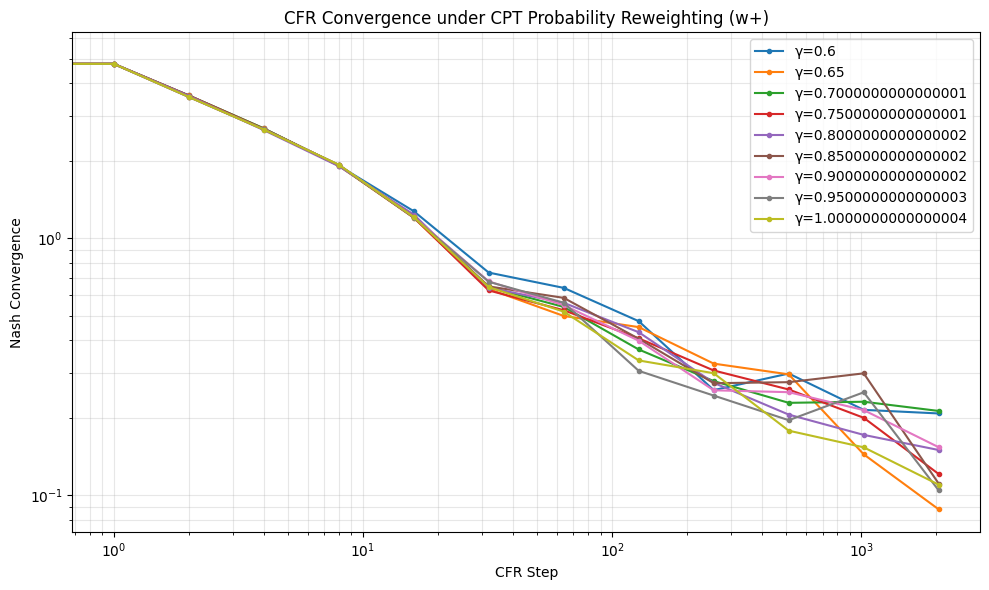

In [67]:
plt.figure(figsize=(10, 6))

for gamma, (steps, nash_convs) in results.items():
    label = f"γ={gamma}" + (" (standard CFR)" if gamma == 1.0 else "")
    plt.plot(steps, nash_convs, marker='o', markersize=3, label=label)

plt.xlabel("CFR Step")
plt.ylabel("Nash Convergence")
plt.title("CFR Convergence under CPT Probability Reweighting (w+)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("cfr_gamma_comparison.png", dpi=150)
plt.show()

## WEIGHTING APPLIED TO CUMULATIVE PROBABILITIES 

from best to worst for gain and viceversa for losses --> this doesn't ensure that sum of distorted prob = 1 

In [47]:
def tk_weight(p, gamma):
    """TK probability weighting function."""
    return p**gamma / (p**gamma + (1 - p)**gamma)**(1 / gamma)

def cpt_weights(probs, utilities, player, gamma_gain=0.61, gamma_loss=0.69):
    """
    Compute CPT decision weights for a given player at an information set.
    
    Steps:
      1. Split actions into gains (u > 0) and losses (u <= 0) for this player
      2. Within each group, sort outcomes worst-to-best
      3. Apply TK weighting on cumulative probabilities (rank-dependent)
      4. Decision weight = w(F(x)) - w(F(x_prev))  [decumulative for gains,
                                                      cumulative for losses]
      5. Recombine gains + losses weights and renormalize to sum to 1
    """
    u = utilities[:, player]           # shape (num_actions,)
    weights = np.zeros_like(probs)

    # --- GAINS (u > 0): rank from best down, use decumulative weighting ---
    gain_mask = u > 0
    if gain_mask.any():
        gain_idx = np.where(gain_mask)[0]
        # Sort best-to-worst (descending) for decumulative transform
        gain_idx = gain_idx[np.argsort(-u[gain_idx])]
        gain_probs = probs[gain_idx]
        cum = 0.0
        for rank, idx in enumerate(gain_idx):
            cum_new = cum + gain_probs[rank]
            weights[idx] = tk_weight(cum_new, gamma_gain) - tk_weight(cum, gamma_gain)
            cum = cum_new

    # --- LOSSES (u <= 0): rank from worst up, use cumulative weighting ---
    loss_mask = u <= 0
    if loss_mask.any():
        loss_idx = np.where(loss_mask)[0]
        # Sort worst-to-best (ascending) for cumulative transform
        loss_idx = loss_idx[np.argsort(u[loss_idx])]
        loss_probs = loss_idx
        loss_probs = probs[loss_idx]
        cum = 0.0
        for rank, idx in enumerate(loss_idx):
            cum_new = cum + loss_probs[rank]
            weights[idx] = tk_weight(cum_new, gamma_loss) - tk_weight(cum, gamma_loss)
            cum = cum_new

    # Renormalize so weights sum to 1
    total = weights.sum()
    if total > 1e-12:
        weights /= total
    else:
        # Fallback: uniform over legal actions
        weights = probs.copy()

    return weights


def new_reach(so_far, player, action_prob):
    """Returns new reach probabilities."""
    new = np.array(so_far)
    new[player] *= action_prob
    return new

def calc_cfr_weighting(state, reach):
    """Updates regrets; returns utility for all players."""
    if state.is_terminal():
        return state.returns()
    elif state.is_chance_node():
        return sum(
            prob * calc_cfr_weighting(state.child(action), new_reach(reach, -1, prob))
            for action, prob in state.chance_outcomes()
        )
    else:
        player = state.current_player()
        index = policy.state_index(state)
        legal = state.legal_actions()

        # --- Compute utilities after each action (recurse) ---
        utility = np.zeros((game.num_distinct_actions(), game.num_players()))
        for action in legal:
            prob = curr_policy[index][action]
            utility[action] = calc_cfr_weighting(
                state.child(action), new_reach(reach, player, prob)
            )

        # --- CPT-distorted probabilities for value computation ---
        # Extract probs and utilities only over legal actions
        legal_arr = np.array(legal)
        legal_probs = curr_policy[index][legal_arr]         # raw policy probs
        cpt_probs = cpt_weights(legal_probs, utility[legal_arr], player, gamma_gain, gamma_loss)

        # --- Counterfactual weight (reach of all OTHER players) ---
        cfr_prob = np.prod(reach[:player]) * np.prod(reach[player + 1:])

        # --- Node value uses CPT-distorted probabilities ---
        # value[p] = sum_a  cpt_prob[a] * utility[a][p]
        value = np.zeros(game.num_players())
        for i, action in enumerate(legal):
            value += cpt_probs[i] * utility[action]

        # --- Regret update still uses raw utility vs CPT-weighted value ---
        for i, action in enumerate(legal):
            regrets[index][action] += cfr_prob * (
                utility[action][player] - value[player]
            )

        return value

In [ ]:
gammas = [0.5, 0.61, 0.69, 0.75, 0.85, 0.95, 1.0]
results_weighting = {}

for gamma_gain in gammas: 
  for gamma_loss in gammas: 
    game = pyspiel.load_game('leduc_poker')
    policy = policy_lib.TabularPolicy(game)
    initial_state = game.new_initial_state()
    curr_policy = policy.action_probability_array.copy()
    regrets = np.zeros_like(policy.action_probability_array)
    eval_steps = []
    eval_nash_conv = []
    print(f'Gamma gain: {gamma_gain}, Gamma loss: {gamma_loss}')
    for step in range(513):
      # Compute regrets
      calc_cfr_weighting(initial_state, np.ones(1 + game.num_players()))

      # Find the new regret-matching policy
      floored_regrets = np.maximum(regrets, 1e-16)
      sum_floored_regrets = np.sum(floored_regrets, axis=1, keepdims=True)
      curr_policy = floored_regrets / sum_floored_regrets

      # Update the average policy
      lr = 1 / (1 + step)
      policy.action_probability_array *= (1 - lr)
      policy.action_probability_array += curr_policy * lr

      # Evaluate the average policy
      if step & (step-1) == 0:
        nc = exploitability.nash_conv(game, policy)
        eval_steps.append(step)
        eval_nash_conv.append(nc)
        print(f'Nash conv after step {step} is {nc}')
    
    results_weighting[(gamma_gain, gamma_loss)] = (eval_steps, eval_nash_conv)

Gamma gain: 0.5, Gamma loss: 0.5
Nash conv after step 0 is 5.063750310669461


/var/folders/56/1yfkkw_j243c09c394_fxr4c0000gn/T/ipykernel_78462/3804160749.py:3: RuntimeWarning: invalid value encountered in scalar power
  return p**gamma / (p**gamma + (1 - p)**gamma)**(1 / gamma)


Nash conv after step 1 is 5.109911312882212
Nash conv after step 2 is 3.6439232423637726
Nash conv after step 4 is 2.3014790855918426
Nash conv after step 8 is 1.5571624683422058
Nash conv after step 16 is 1.326399400173838
Nash conv after step 32 is 0.7768589250384471
Nash conv after step 64 is 0.6067344804212134
Nash conv after step 128 is 0.5428112524713447
Nash conv after step 256 is 0.286609070852338
Nash conv after step 512 is 0.20222114316557863
Gamma gain: 0.5, Gamma loss: 0.61
Nash conv after step 0 is 5.826712748251561
Nash conv after step 1 is 4.538450808470849
Nash conv after step 2 is 3.513949564526681
Nash conv after step 4 is 2.348750782012341
Nash conv after step 8 is 1.655401248957512
Nash conv after step 16 is 1.1449625750744348
Nash conv after step 32 is 0.7772752514330452
Nash conv after step 64 is 0.6540035746232906
Nash conv after step 128 is 0.44856778621410265
Nash conv after step 256 is 0.31241697282221875
Nash conv after step 512 is 0.2110642480400319
Gamma ga

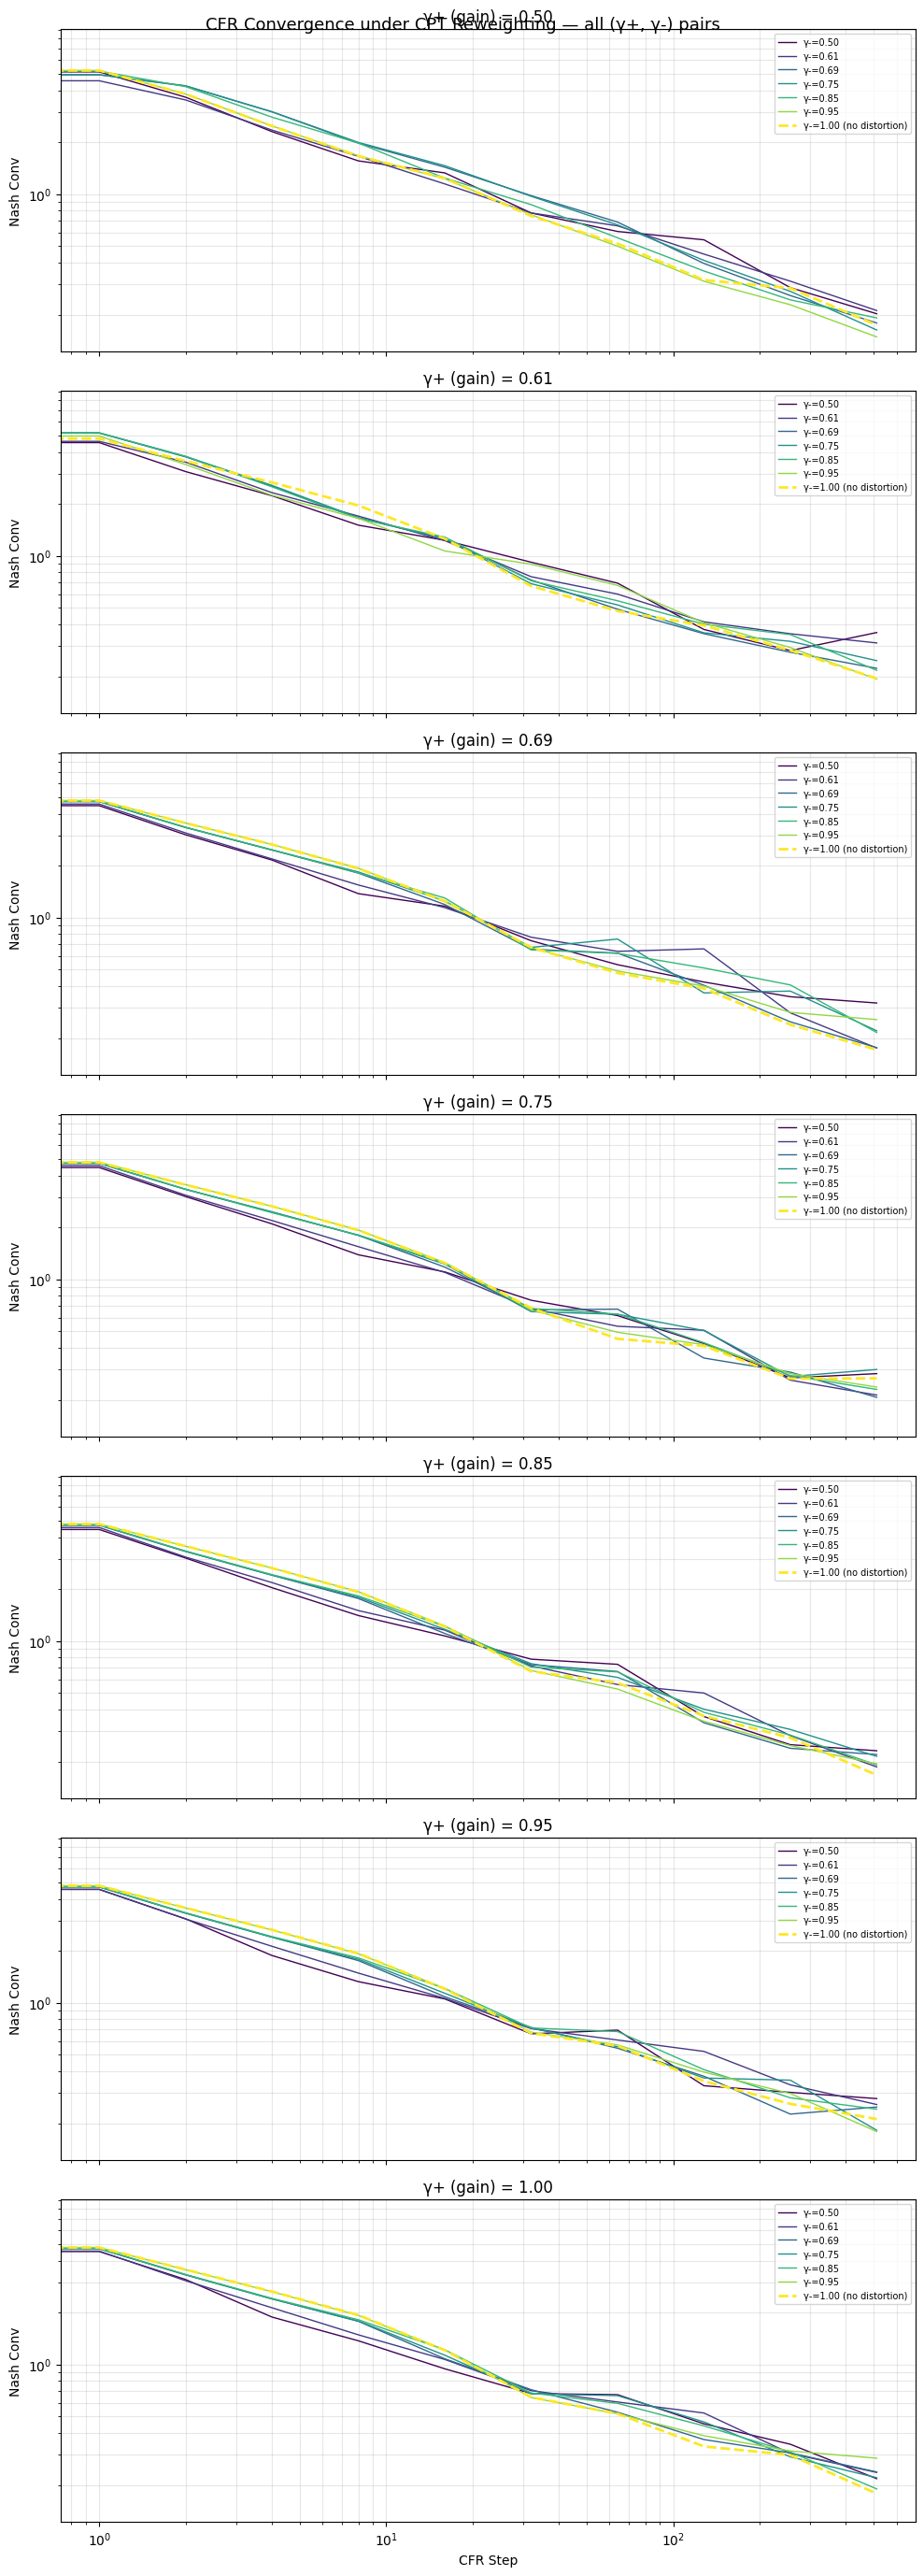

In [ ]:
fig, axes = plt.subplots(len(gammas), 1, figsize=(10, 4 * len(gammas)), sharex=True, sharey=True)

colors = plt.cm.viridis(np.linspace(0, 1, len(gammas)))

for i, gamma_gain in enumerate(gammas):
    ax = axes[i]
    for j, gamma_loss in enumerate(gammas):
        steps, nc = results_weighting[(gamma_gain, gamma_loss)]
        label = f'γ-={gamma_loss:.2f}' + (' (no distortion)' if gamma_loss == 1.0 else '')
        lw = 2.0 if gamma_loss == 1.0 else 1.0
        ls = '--' if gamma_loss == 1.0 else '-'
        ax.plot(steps, nc, label=label, color=colors[j], linewidth=lw, linestyle=ls)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'γ+ (gain) = {gamma_gain:.2f}')
    ax.set_ylabel('Nash Conv')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)

axes[-1].set_xlabel('CFR Step')
plt.suptitle('CFR Convergence under CPT Reweighting — all (γ+, γ-) pairs', fontsize=13)
plt.tight_layout()
plt.savefig('cfr_all_gamma_pairs.png', dpi=150)
plt.show()

do same rank for both cases so can ensure that sum = 1 

In [55]:
def cpt_weights_wb(probs, utilities, player, gamma_gain=0.61, gamma_loss=0.69):
    """
    CPT decision weights following Tversky-Kahneman (1992):
    - Sort all outcomes worst-to-best in a single pass
    - Build cumulative probabilities from the bottom up
    - Switch between gamma+ and gamma- depending on sign of outcome
    - Decision weight = w(F_i) - w(F_{i-1})
    - Sum to 1 is guaranteed by the telescoping construction
    """
    u = utilities[:, player]
    n = len(probs)
    weights = np.zeros(n)

    # Single pass: sort all outcomes worst-to-best
    sorted_order = np.argsort(u)

    cum = 0.0
    prev_w = 0.0
    for idx in sorted_order:
        cum += probs[idx]
        gamma = gamma_gain if u[idx] >= 0 else gamma_loss
        w_cum = tk_weight(cum, gamma)
        weights[idx] = w_cum - prev_w
        prev_w = w_cum

    # Renormalization as numerical safety net only
    total = weights.sum()
    if total > 1e-12:
        weights /= total
    else:
        weights = probs.copy()

    return weights


def calc_cfr_weighting_wb(state, reach):
    """Updates regrets; returns utility for all players."""
    if state.is_terminal():
        return state.returns()
    elif state.is_chance_node():
        return sum(
            prob * calc_cfr_weighting_wb(state.child(action), new_reach(reach, -1, prob))
            for action, prob in state.chance_outcomes()
        )
    else:
        player = state.current_player()
        index = policy.state_index(state)
        legal = state.legal_actions()

        # --- Compute utilities after each action (recurse) ---
        utility = np.zeros((game.num_distinct_actions(), game.num_players()))
        for action in legal:
            prob = curr_policy[index][action]
            utility[action] = calc_cfr_weighting_wb(
                state.child(action), new_reach(reach, player, prob)
            )

        # --- CPT-distorted probabilities for value computation ---
        # Extract probs and utilities only over legal actions
        legal_arr = np.array(legal)
        legal_probs = curr_policy[index][legal_arr]         # raw policy probs
        cpt_probs = cpt_weights_wb(legal_probs, utility[legal_arr], player, gamma_gain, gamma_loss)

        # --- Counterfactual weight (reach of all OTHER players) ---
        cfr_prob = np.prod(reach[:player]) * np.prod(reach[player + 1:])

        # --- Node value uses CPT-distorted probabilities ---
        # value[p] = sum_a  cpt_prob[a] * utility[a][p]
        value = np.zeros(game.num_players())
        for i, action in enumerate(legal):
            value += cpt_probs[i] * utility[action]

        # --- Regret update still uses raw utility vs CPT-weighted value ---
        for i, action in enumerate(legal):
            regrets[index][action] += cfr_prob * (
                utility[action][player] - value[player]
            )

        return value

In [57]:
results_weighting_wb = {}
for gamma_gain in gammas: 
  for gamma_loss in gammas: 
    game = pyspiel.load_game('leduc_poker')
    policy = policy_lib.TabularPolicy(game)
    initial_state = game.new_initial_state()
    curr_policy = policy.action_probability_array.copy()
    regrets = np.zeros_like(policy.action_probability_array)
    eval_steps = []
    eval_nash_conv = []
    for step in range(513):
      # Compute regrets
      calc_cfr_weighting_wb(initial_state, np.ones(1 + game.num_players()))

      # Find the new regret-matching policy
      floored_regrets = np.maximum(regrets, 1e-16)
      sum_floored_regrets = np.sum(floored_regrets, axis=1, keepdims=True)
      curr_policy = floored_regrets / sum_floored_regrets

      # Update the average policy
      lr = 1 / (1 + step)
      policy.action_probability_array *= (1 - lr)
      policy.action_probability_array += curr_policy * lr

      # Evaluate the average policy
      if step & (step-1) == 0:
        nc = exploitability.nash_conv(game, policy)
        eval_steps.append(step)
        eval_nash_conv.append(nc)
        print(f'Nash conv after step {step} is {nc}')
    
    results_weighting_wb[(gamma_gain, gamma_loss)] = (eval_steps, eval_nash_conv)

Nash conv after step 0 is 4.414125288061338


/var/folders/56/1yfkkw_j243c09c394_fxr4c0000gn/T/ipykernel_78462/3804160749.py:3: RuntimeWarning: invalid value encountered in scalar power
  return p**gamma / (p**gamma + (1 - p)**gamma)**(1 / gamma)


Nash conv after step 1 is 4.271192560755062
Nash conv after step 2 is 2.8850616496068455
Nash conv after step 4 is 1.820065652266603
Nash conv after step 8 is 1.397682203417517
Nash conv after step 16 is 1.0123533007009753
Nash conv after step 32 is 0.7751222250811679
Nash conv after step 64 is 0.5833885056238168
Nash conv after step 128 is 0.4625574347163776
Nash conv after step 256 is 0.30801323850022533
Nash conv after step 512 is 0.27125843126804033
Nash conv after step 0 is 4.454805961847233
Nash conv after step 1 is 4.317146329487914
Nash conv after step 2 is 3.0821440160503997
Nash conv after step 4 is 1.91290730394526
Nash conv after step 8 is 1.3314801535979282
Nash conv after step 16 is 1.0934440589122003
Nash conv after step 32 is 0.8039140546329475
Nash conv after step 64 is 0.5352192153836652
Nash conv after step 128 is 0.44375330518836
Nash conv after step 256 is 0.27978923619574336
Nash conv after step 512 is 0.27201608360438606
Nash conv after step 0 is 6.37030418888430

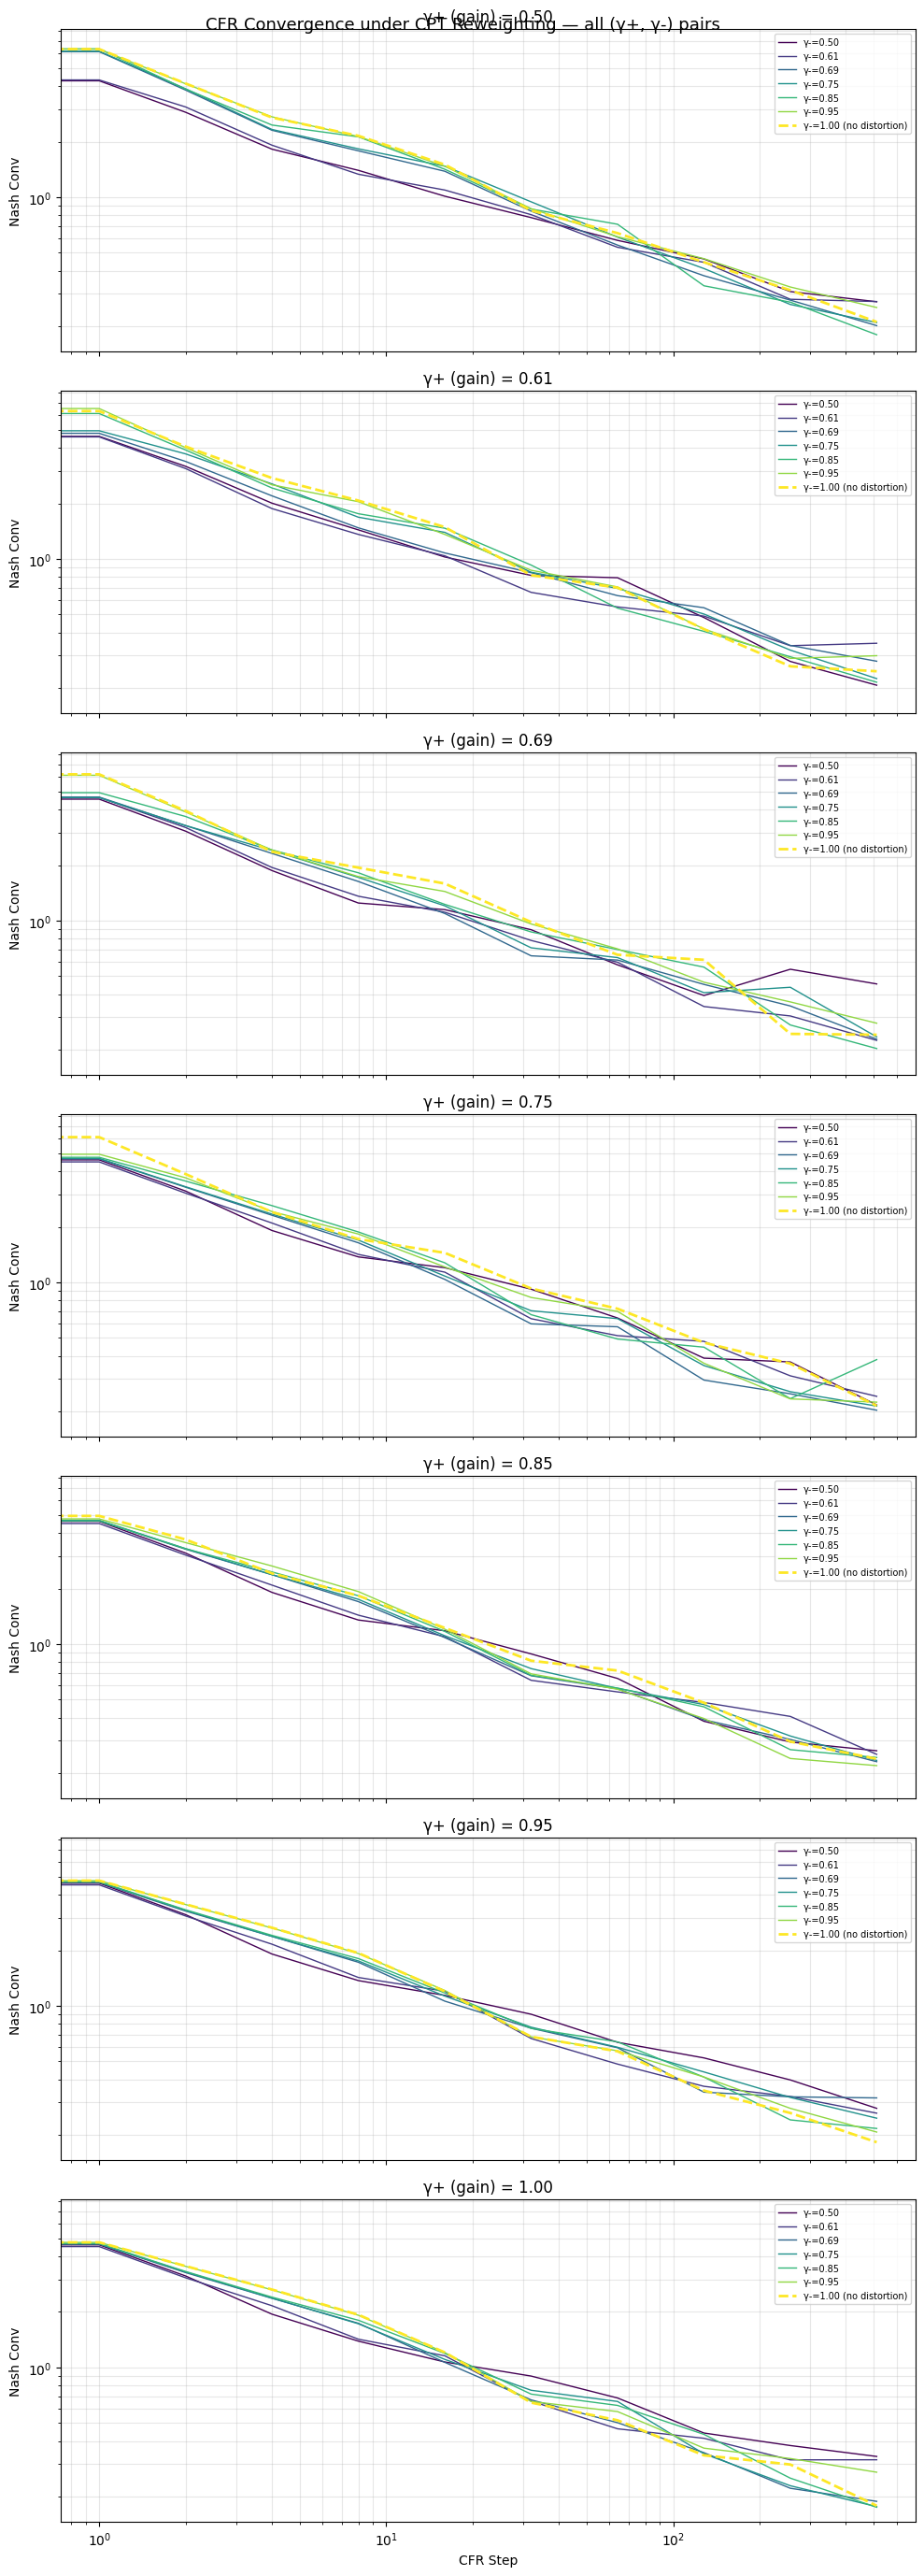

In [58]:
fig, axes = plt.subplots(len(gammas), 1, figsize=(10, 4 * len(gammas)), sharex=True, sharey=True)

colors = plt.cm.viridis(np.linspace(0, 1, len(gammas)))

for i, gamma_gain in enumerate(gammas):
    ax = axes[i]
    for j, gamma_loss in enumerate(gammas):
        steps, nc = results_weighting_wb[(gamma_gain, gamma_loss)]
        label = f'γ-={gamma_loss:.2f}' + (' (no distortion)' if gamma_loss == 1.0 else '')
        lw = 2.0 if gamma_loss == 1.0 else 1.0
        ls = '--' if gamma_loss == 1.0 else '-'
        ax.plot(steps, nc, label=label, color=colors[j], linewidth=lw, linestyle=ls)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'γ+ (gain) = {gamma_gain:.2f}')
    ax.set_ylabel('Nash Conv')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)

axes[-1].set_xlabel('CFR Step')
plt.suptitle('CFR Convergence under CPT Reweighting — all (γ+, γ-) pairs', fontsize=13)
plt.tight_layout()
plt.savefig('cfr_all_gamma_pairs_wb.png', dpi=150)
plt.show()

gamma = 0.61 
delta = 0.69 by TK 